## 2602052613 - Jovian Yanto
## UTS model deplyoment

- Problem case: customer churn prediction

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [91]:
data = pd.read_csv('data_A.csv')

In [92]:
data.head()

,Unnamed: 0,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn
0,0,7317,15637411,Tochukwu,749.0,France,Male,30.0,1,0.00,2,0,0,126551.65,1
1,1,11125,15745307,Martin,683.0,Germany,Male,32.0,7,121887.91,1,1,1,176570.46,0
2,2,45720,15677382,Aitken,711.0,Spain,Female,33.0,5,0.00,2,1,0,162703.80,0
3,3,74042,15694450,Tuan,722.0,France,Female,28.0,4,0.00,2,1,1,76615.31,0
4,4,109985,15734987,Aitken,754.0,France,Female,67.0,3,0.00,2,1,1,114514.92,0


In [25]:
data.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41258 entries, 0 to 41257
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       41258 non-null  int64  
 1   id               41258 non-null  int64  
 2   CustomerId       41258 non-null  int64  
 3   Surname          41258 non-null  object 
 4   CreditScore      41238 non-null  float64
 5   Geography        41258 non-null  object 
 6   Gender           41258 non-null  object 
 7   Age              41258 non-null  float64
 8   Tenure           41258 non-null  int64  
 9   Balance          41258 non-null  float64
 10  NumOfProducts    41258 non-null  int64  
 11  HasCrCard        41258 non-null  int64  
 12  IsActiveMember   41258 non-null  int64  
 13  EstimatedSalary  41258 non-null  float64
 14  churn            41258 non-null  int64  
dtypes: float64(4), int64(8), object(3)
memory usage: 4.7+ MB


In [26]:
data_class = ['Geography', 'Gender', 'churn']

for i in data_class:
    print(data[i].value_counts())

France     23518
Spain       9114
Germany     8626
Name: Geography, dtype: int64
Male      23341
Female    17917
Name: Gender, dtype: int64
0    32645
1     8613
Name: churn, dtype: int64


In [27]:
# one hot encode

col = ['Geography', 'Gender']

data = pd.get_dummies(data, columns=col)

In [28]:
data.head()

,Unnamed: 0,id,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,0,7317,15637411,Tochukwu,749.0,30.0,1,0.00,2,0,0,126551.65,1,1,0,0,0,1
1,1,11125,15745307,Martin,683.0,32.0,7,121887.91,1,1,1,176570.46,0,0,1,0,0,1
2,2,45720,15677382,Aitken,711.0,33.0,5,0.00,2,1,0,162703.80,0,0,0,1,1,0
3,3,74042,15694450,Tuan,722.0,28.0,4,0.00,2,1,1,76615.31,0,1,0,0,1,0
4,4,109985,15734987,Aitken,754.0,67.0,3,0.00,2,1,1,114514.92,0,1,0,0,1,0


In [29]:
data.columns

Index(['Unnamed: 0', 'id', 'CustomerId', 'Surname', 'CreditScore', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'churn', 'Geography_France', 'Geography_Germany',
       'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='object')

In [50]:
features = data.drop(['Unnamed: 0', 'id', 'CustomerId', 'Surname', 'churn'],axis=1)
label = data['churn']

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.2, random_state = 42)

<AxesSubplot:>

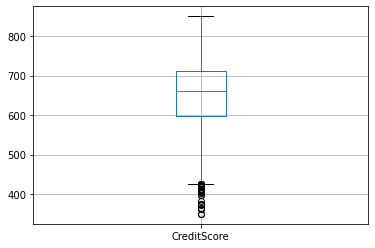

In [52]:
x_train.boxplot(column=['CreditScore']) 

In [53]:
print(x_test['CreditScore'].median())

662.0


In [54]:
x_train['CreditScore'].fillna(660.0, inplace=True)
x_test['CreditScore'].fillna(662.0, inplace=True)

In [55]:
print(x_train.isnull().sum())
print(x_test.isnull().sum())

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Geography_France     0
Geography_Germany    0
Geography_Spain      0
Gender_Female        0
Gender_Male          0
dtype: int64
CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Geography_France     0
Geography_Germany    0
Geography_Spain      0
Gender_Female        0
Gender_Male          0
dtype: int64


In [67]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

RF_class = RandomForestClassifier(criterion= 'entropy',max_depth=4)
RF_class.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=4)

In [68]:
y_predict=RF_class.predict(x_test)
from sklearn.metrics import classification_report
print('\nClassification Report\n')
print(classification_report(y_test, y_predict))


Classification Report

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6545
           1       0.81      0.33      0.47      1707

    accuracy                           0.85      8252
   macro avg       0.83      0.65      0.69      8252
weighted avg       0.84      0.85      0.82      8252



Hypertuning Random forest

In [97]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

RF_class = RandomForestClassifier()

# Define the hyperparameters grid to search over
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4]
}

# Define Grid Search Cross-Validation
grid_search = GridSearchCV(estimator=RF_class, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Perform the Grid Search
grid_search.fit(x_train, y_train)

# Print the best parameters and best score found
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best Score: 0.8639943292996147


In [98]:
RF_class = RandomForestClassifier(max_depth= 8, min_samples_leaf= 2, min_samples_split= 5, n_estimators= 50)
RF_class.fit(x_train, y_train)
y_predict=RF_class.predict(x_test)
print('\nClassification Report\n')
print(classification_report(y_test, y_predict))


Classification Report

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      6545
           1       0.77      0.47      0.59      1707

    accuracy                           0.86      8252
   macro avg       0.82      0.72      0.75      8252
weighted avg       0.85      0.86      0.85      8252



In [78]:
from xgboost import  XGBClassifier

XGB_class = XGBClassifier()
XGB_class.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [79]:
y_predict=XGB_class.predict(x_test)
print('\nClassification Report\n')
print(classification_report(y_test, y_predict))


Classification Report

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      6545
           1       0.71      0.55      0.62      1707

    accuracy                           0.86      8252
   macro avg       0.80      0.75      0.77      8252
weighted avg       0.85      0.86      0.85      8252



Hypertuning XGBoost

In [80]:
XGB_class = XGBClassifier()

# Define the hyperparameters grid to search over
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.5, 0.7],
    'gamma': [5, 10]
}

# Define Grid Search Cross-Validation
grid_search = GridSearchCV(estimator=XGB_class, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Perform the Grid Search
grid_search.fit(x_train, y_train)

# Print the best parameters and best score found
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'gamma': 10, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.7}
Best Score: 0.8665999721614155


In [81]:
XGB_class = XGBClassifier(gamma= 10, learning_rate= 0.2, max_depth= 5, n_estimators= 50, subsample= 0.7)
XGB_class.fit(x_train, y_train)
y_predict=XGB_class.predict(x_test)
print('\nClassification Report\n')
print(classification_report(y_test, y_predict))


Classification Report

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6545
           1       0.75      0.55      0.64      1707

    accuracy                           0.87      8252
   macro avg       0.82      0.75      0.78      8252
weighted avg       0.86      0.87      0.86      8252



###  XGBoost Classifier slighty better than Random Forest Classifier but overall the same, i will be using random forest instead because in the streamlit app there will be another installation process  for xgboost and for time efficiency  Random Forest is more suitable.

Save to .pkl for deployment

In [89]:
import pickle

with open("RF_class.pkl", "wb") as f:
    pickle.dump(RF_class, f)

In [85]:
x_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
15731,634.0,53.0,2,181821.96,2,1,1,36980.54,1,0,0,0,1
6996,581.0,50.0,9,117565.03,2,0,0,82559.77,1,0,0,1,0
30824,545.0,34.0,9,0.00,2,1,0,66393.89,1,0,0,0,1
40019,543.0,26.0,10,117837.43,1,1,0,160528.65,0,0,1,0,1
21501,733.0,48.0,9,0.00,1,1,0,127569.80,0,0,1,0,1


In [49]:
y_train.head()

15731    0
6996     0
30824    0
40019    0
21501    0
Name: churn, dtype: int64

Testing loaded model and make a prediction

In [90]:
loaded_model = pickle.load(open("RF_class.pkl", "rb"))

input_data = (634.0, 53.0, 2, 181821.96, 2, 1, 1, 36980.54, 1, 0, 0, 0, 1)

input_data_asnumpy = np.array(input_data)

input_datareshaped = input_data_asnumpy.reshape(1, -1)

prediction = loaded_model.predict(input_datareshaped)

print(prediction)

[0]
